best parametri: {'n_neighbors': 3}
Accuracy: 0.91775
Precision: 0.11666666666666667
Recall: 0.024734982332155476
F1: 0.04081632653061224


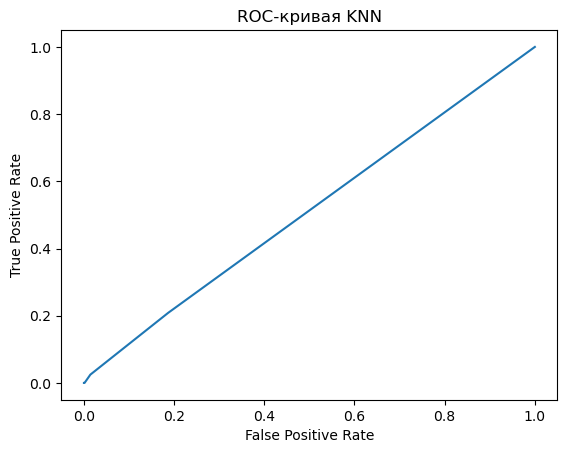

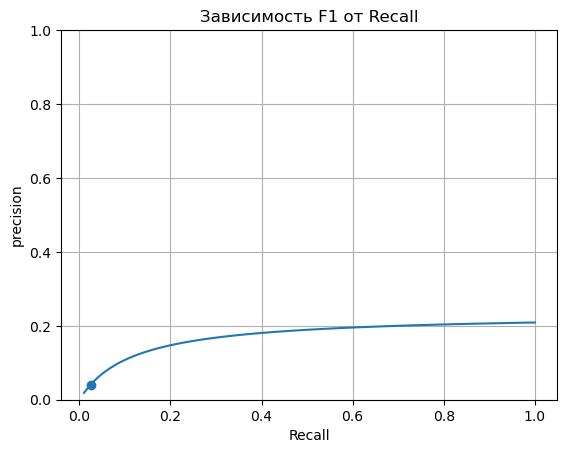

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)

df = pd.read_csv("NormalDliaObucenija.csv")

X = df.drop(columns=["battery_failure"])
y = df["battery_failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier()

n_sosedej = {
    "n_neighbors": [3, 5, 7, 9, 11, 15]
}

grid = GridSearchCV(model, n_sosedej, scoring="f1")  # 3 Аругмент это параметр по которому ищем лучшее

grid.fit(X_train, y_train)

print("best parametri:", grid.best_params_)

y_pred = grid.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

y_proba = grid.predict_proba(X_test)[:, 1] # Возвращает вероятность принадлежности к 
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая KNN")
plt.show()



Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best parameters: {'C': 0.1, 'kernel': 'linear'}
Accuracy: 0.93475
Precision: 0.6666666666666666
Recall: 0.11552346570397112
F1: 0.19692307692307692
ROC-AUC: 0.8182087928391276


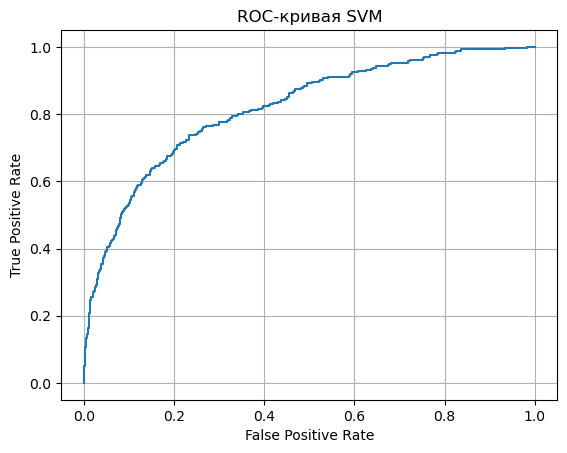

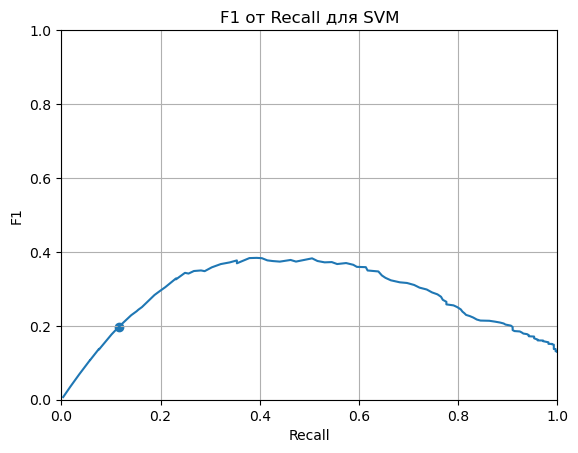

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

df = pd.read_csv("NormalDliaObucenija.csv")

X = df.drop(columns=["battery_failure"])
y = df["battery_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# grid

# 5000 объектов для поиска параметров
X_search, _, y_search, _ = train_test_split(
    X_train,
    y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(),
    params,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_search, y_search)

print("Best parameters:", grid.best_params_)


model = SVC(
    C=grid.best_params_["C"],
    kernel=grid.best_params_["kernel"]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

# ROC-AUC

y_score = model.decision_function(X_test)

roc_auc = roc_auc_score(y_test, y_score)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_score)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая SVM")
plt.grid()
plt.show()

# F1 / RECALL ПРИ РАЗНЫХ ПОРОГАХ

threshold_values = np.linspace(
    y_score.min(),
    y_score.max(),
    200
)

recall_values = []
f1_values = []

for threshold in threshold_values:

    y_pred_threshold = (y_score >= threshold).astype(int)

    recall_threshold = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1_threshold = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall_values.append(recall_threshold)
    f1_values.append(f1_threshold)

plt.plot(recall_values, f1_values)

# Обычный predict()
plt.scatter(recall, f1)

plt.xlabel("Recall")
plt.ylabel("F1")
plt.title("F1 от Recall для SVM")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.show()